In [577]:
import numpy as np
import matplotlib.pyplot as plt

# Molecular Dynamics and Ergodicity


The primary goal of Molecular Dynamics (MD) is to simulate the time evolution of a system of interacting particles. It essentially acts as a "computational microscope" , allowing us to derive macroscopic thermodynamic quantities starting from microscopic positions and velocities.

In statistical mechanics, macroscopic observables are formally defined as ensemble averages. In an MD simulation (as we do on a real experiment), however, we evaluate physical properties as time averages over the trajectories generated by the computer. The bridge connecting these two approaches is the ergodic hypothesis. This hypothesis states that, for sufficiently long time intervals, the time average of an observable is equal to its ensemble average.

Through the exercise, instead of simulating countless copies of the system to build an ensemble, we simulate a single system over a large number of time blocks. By measuring quantities like energy or temperature over these extended periods, we can safely assume that the computed time averages represent the true macroscopic values of the system at thermodynamic equilibrium.


## Maxwell-Boltzmann distribution

One such macroscopic property of interest is the velocity distribution of the particles. In Statistical Mechanics, the Maxwell–Boltzmann distribution is a probability distribution used to describe particle speeds in idealized gases. Since rarefied gases at ordinary temperatures behave very much like an ideal gas, this distribution serves as an excellent approximation for our Lennard-Jones system in the gas phase.

For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (lenght: $\sigma$; energy: $\epsilon$; mass: the mass, $m$, of the particles; temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The definition of the Maxwell-Boltzmann distribution is given in the following cell.

In [578]:
# ==========================================
# MAXWELL-BOLTZMANN THEORETICAL FUNCTION
# ==========================================

def maxwell_boltzmann(v, T):
    prefactor = (1.0 / np.power(2 * np.pi * T, 1.5)) * 4 * np.pi
    return prefactor * (v**2) * np.exp(-(v**2) / (2 * T))

## Verlet algorithm

In statistical mechanics, the macroscopic value of an observable $f(q, p)$ is theoretically defined as its ensemble average in phase space:

$$\langle f(q, p) \rangle = \frac{\int f(q, p) \rho(q, p, t) \, d^{3N}q \, d^{3N}p}{\int \rho(q, p, t) \, d^{3N}q \, d^{3N}p}$$

where $\rho(q, p, t)$ is the probability density of the system's states.
Evaluating this high-dimensional integral via standard numerical quadrature is computationally impossible even for a small number of particles. 

Molecular Dynamics overcomes this issue by effectively performing an importance sampling: instead of scanning the entire phase space blindly, the system naturally explores the relevant regions by following the classical trajectories of the particles. 

To obtain this time evolution, we must numerically integrate Newton's equations of motion. For this purpose, we used the **Verlet algorithm**. This method is based on a third-order Taylor expansion of the atomic coordinates. It computes the new position at time $t+\delta t$ using the current position $\vec{r}(t)$, the previous position $\vec{r}(t-\delta t)$, and the current acceleration $\vec{a}(t)$. 

$$\vec{r}(t+\delta t) = 2\vec{r}(t) - \vec{r}(t-\delta t) + \vec{a}(t) (\delta t)^2 $$

This algorithm is highly advantageous because it is strictly time-reversible and computes the spatial trajectory without explicitly needing the particles' velocities.

Most importantly for our purposes, the Verlet algorithm exhibits excellent long-term energy conservation. Since our fundamental goal is to sample microstates from the microcanonical ensemble, it is crucial that the simulated trajectories remain tightly bound to the correct constant-energy hypersurface in phase space. Verlet's stability prevents the total energy from drifting over long simulations, guaranteeing that we generate correct thermodynamic ensemble averages even when the exact microscopic trajectory is lost due to chaos and finite precision.

## Lennard-Jones potential and PBC

#### Periodic Boundary Conditions (PBC)
Simulating a bulk macroscopic system with a limited number of particles (e.g., $N=108$) introduces a major issue: a large fraction of the molecules would lie on the surface of the simulation box, experiencing vastly different forces compared to those in the bulk. To overcome these surface effects, we implement Periodic Boundary Conditions (PBCs). The central cubic box is virtually replicated throughout space to form an infinite lattice. When a molecule moves within the original box, its _periodic images_ in the neighboring boxes move in exactly the same way; if a particle exits the central box through one face, its image simultaneously enters through the opposite face, keeping the density strictly constant.

#### Lennard-Jones potential
The interaction between the molecules is modeled by a pairwise additive force derived from the Lennard-Jones (LJ) potential:

$$V_{LJ}(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]$$
where $r$ is the distance between the two interacting molecules, $\sigma$ is the typical distance at which the interaction potential vanishes (determined by the particle's effective size), and $\epsilon$ is the depth of the potential well (representing the strength of the attraction).

Under PBCs, a particle conceptually interacts with infinitely many periodic images. Because the LJ potential is short-ranged, we can safely apply the _minimum image convention_, restricting a particle to interact only with the single closest periodic image of the other $N-1$ molecules. This convention still leaves $N(N-1)/2$ pairwise terms to evaluate at each step. To further reduce the computational load, we introduce a spherical cutoff $r_c$. By explicitly setting $v(r) = 0$ for any distance $r > r_c$, we safely ignore negligible distant interactions and significantly speed up the simulation.

## Reduced units

In computational physics, it is highly convenient to express quantities such as temperature, density, and pressure in reduced (dimensionless) units.

The rescaled quantities of interest are so defined:

| Quantity | Reduced Unit | Expression |
| :--- | :---: | :---: |
| **Length** | $r^*$ | $\frac{r}{\sigma}$ |
| **Time** | $t^*$ | $t \sqrt{\frac{\epsilon}{m \sigma^2}}$ |
| **Temperature** | $T^*$ | $\frac{k_B T}{\epsilon}$ |
| **Force** | $F^*$ | $\frac{F \sigma}{\epsilon}$ |
| **Energy** | $U^*$ | $\frac{U}{\epsilon}$ |
| **Pressure** | $p^*$ | $\frac{p \sigma^3}{\epsilon}$ |
| **Density** | $\rho^*$ | $\rho \sigma^3$ |

In these units, the Lennard-Jones potential is written as

$$V^*(r^*) = \frac{V(r)}{\epsilon} = 4 \left[ \left(\frac{1}{r^*}\right)^{12} - \left(\frac{1}{r^*}\right)^6 \right]$$


Expressing quantities in reduced units serves two main purposes:

1. Universality: different systems described by the same interacting potential give the same numerical results when simulated. For instance Ar at $60\, \text{K}$ and density of $840\, \text{kg}/\text{m}^3$ and Xe at $112\, \text{K}$ and a density of $1617\, \text{kg}/\text{m}^3$ both correspond to the state point $r^* = 0.5$, $T^*=0.5$. If we had not used reduced units we might have missed the equivalence of these two simulations;
2. Avoids precision errors: quantities in reduced units are in the order of magnitude of unity, whereas in physical units they would be either very large or very small, close to the representation limit of the computer. Such a situation could lead to underflow or overflow.

# Analysis Exercise 4.1: sampling speed distribution

In [579]:
# ==========================================
# PATHS
# ==========================================

path = "NSL_SIMULATOR/OUTPUT/" # if the files in OUTPUT have been deleted, a successful simulation result is stored in OUTPUT/BACKUP/EX4.1/
# Comment the previous line and uncomment the following one if the files in OUTPUT get lost
#path = "NSL_SIMULATOR/OUTPUT/BACKUP/EX4.1/" 

The goal of this first exercise is to implement the measurement of the speed distribution inside the Molecular Dynamics simulation code and compute its values using the data blocking method.

## System Initialization

To begin the simulation, the system must be properly initialized. To generate the initial spatial configuration, the ideal FCC lattice `NSL_SIMULATOR/INPUT/CONFIG/config.fcc` was copied into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`. We explicitly avoid random spatial initialization because it carries a high risk of placing particles unphysically close to one another. Due to the steep repulsive core of the Lennard-Jones potential (the $r^{-12}$ term), such overlaps would generate immense repulsive forces. As a result, the particles would violently shoot apart during the first integration steps, artificially causing a massive spike in kinetic energy and completely destabilizing the target temperature of the system.

The starting velocities, instead, are sampled by drawing the individual spatial components ($v_x, v_y, v_z$) from a Gaussian distribution centered at zero with a standard deviation equal to the square root of the target temperature.

To represent a proper experimental setup, the total linear momentum of the system is forced to be zero (subtracting the average center-of-mass velocity) to avoid macroscopic drift. 

Due to the finite number of particles in the simulation (e.g., $N = 108$), the initial velocities sampled from the Gaussian distribution will not perfectly reproduce the desired macroscopic temperature. This discrepancy is a direct consequence of statistical fluctuations within a small sample. 
In a gas, the temperature is directly proportional to the average kinetic energy of the system. Using Lennard-Jones reduced units, this relationship is expressed as:

$$T^* = \frac{\langle (v^*)^2 \rangle}{3}$$

where $\langle (v^*)^2 \rangle$ is the mean squared velocity of the particles. 

To enforce the exact target temperature required by the input file (in this case $T^*=2.0$) from the very first integration step, we must artificially correct the system's kinetic energy. We compute the ratio between the desired target temperature and the actual measured temperature of the randomly sampled velocities:

$$\mathcal{R} = \frac{T_{\text{target}}}{T_{\text{measured}}} = \frac{T_{\text{target}}}{\langle (v^*)^2 \rangle / 3.0}$$

Since the temperature scales with the square of the velocity ($T \propto v^2$), we must multiply the individual velocity components of each particle by the square root of this ratio. This yields the velocity scaling factor:

$$\text{scalef} = \sqrt{\frac{3.0 \cdot T_{\text{target}}}{\langle (v^*)^2 \rangle}}$$

By multiplying every particle's velocity by this factor, we ensure that the initial kinetic energy is perfectly matched to the exact input temperature before the Molecular Dynamics integration begins. 

From these velocities, the "past" spatial coordinates $\vec{r}(t-\Delta t)$ are derived to jump-start the Verlet integration algorithm.

## Simulation Parameters and Reference Temperature
The simulation was run setting the number of blocks to `NBLOCKS = 40` and the number of integration steps to `NSTEPS = 10000` in `NSL_SIMULATOR/INPUT/input.dat`. Given the length of the blocks, the system quickly approaches equilibrium. However, looking at the progressive temperature plot, an initial transient is still present. To obtain a highly accurate reference temperature $T^*$ to evaluate the theoretical Maxwell-Boltzmann curve, the instantaneous block temperatures were averaged excluding the initial thermalization phase (averaging strictly from block 10 to block 40).

============ Mean equilibrium temperature (averaged on blocks from 16 to 40): T* = 2.1916 ============


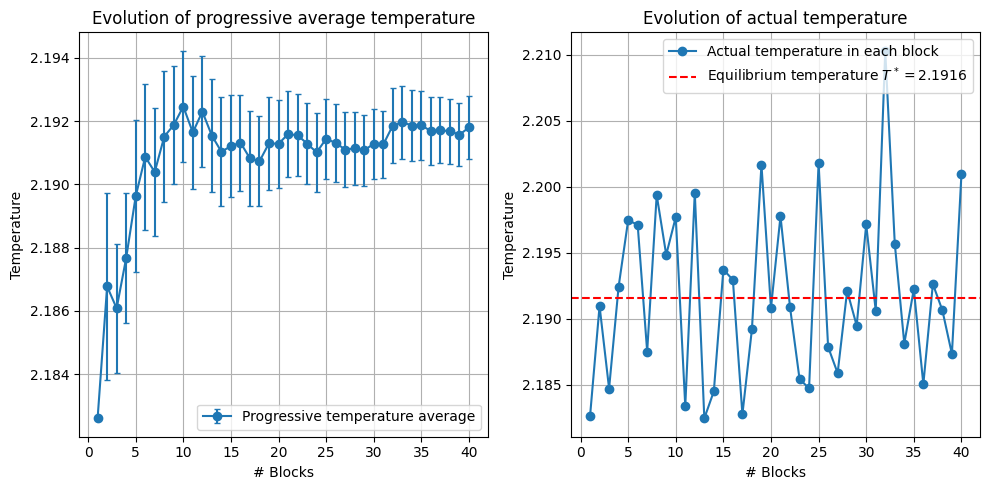

In [580]:
try:
    # Load temperature data
    blocks, actual_T, av_T, err_T = np.loadtxt(path + 'temperature.dat', unpack=True)
    
except FileNotFoundError:
    print("ERROR: File " + path + "'OUTPUT/temperature.dat' not found.")
    print("Try changing path to 'NSL_SIMULATOR/OUTPUT/BACKUP/EX4.1/' if the files in OUTPUT have been deleted.")
    exit()

# Calculate the equilibrium temperature avoiding the initial thermalization phase
thermalized_temperatures = actual_T[10:]
T_final = np.mean(thermalized_temperatures)

print(f"============ Mean equilibrium temperature (averaged on blocks from 16 to 40): T* = {T_final:.4f} ============")

_, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Plot the progressive average temperature with error bars
ax1.errorbar(blocks, av_T, yerr=err_T, fmt='o-', capsize=2.5, label='Progressive temperature average')
ax1.set_xlabel('# Blocks')
ax1.set_ylabel('Temperature')
ax1.set_title('Evolution of progressive average temperature')
ax1.legend()
ax1.grid()

# Plot the actual temperature in each block
ax2.plot(blocks, actual_T, marker='o', label='Actual temperature in each block')
ax2.axhline(T_final, color='red', linestyle='--', label=f'Equilibrium temperature $T^* = {T_final:.4f}$')
ax2.set_xlabel('# Blocks')
ax2.set_ylabel('Temperature')
ax2.set_title('Evolution of actual temperature')
ax2.legend()
ax2.grid()

plt.tight_layout()


## Histogram Implementation and Data Blocking
The probability distribution $p(v^*,T^*)$ was computed as a normalized histogram of the velocity magnitudes over an interval $[0, v_{max}]$. The number of bins was set to 30. During the implementation, the dynamic upper limit of the histogram was manually extended to $v_{max} = 5.0 \times T^*$ (instead of the default 4.0). This adjustment ensures a wider sampling window, capturing the entire high-energy exponential tail of the Maxwell-Boltzmann distribution without truncating the data of rare, high-speed particles.

At each integration step, the module of the velocity of every particle is calculated to populate the histogram, which is then normalized by the factor 

$$\text{norm} = \text{number of particles} \times \text{bin size}$$

Finally, the data blocking technique was applied to the histogram bins to compute the progressive averages and their statistical uncertainties. Using blocks of 5000 steps effectively removes the intrinsic autocorrelation of the Molecular Dynamics time-series. The final distribution presented in the plots corresponds to the cumulative average evaluated at the very last block.

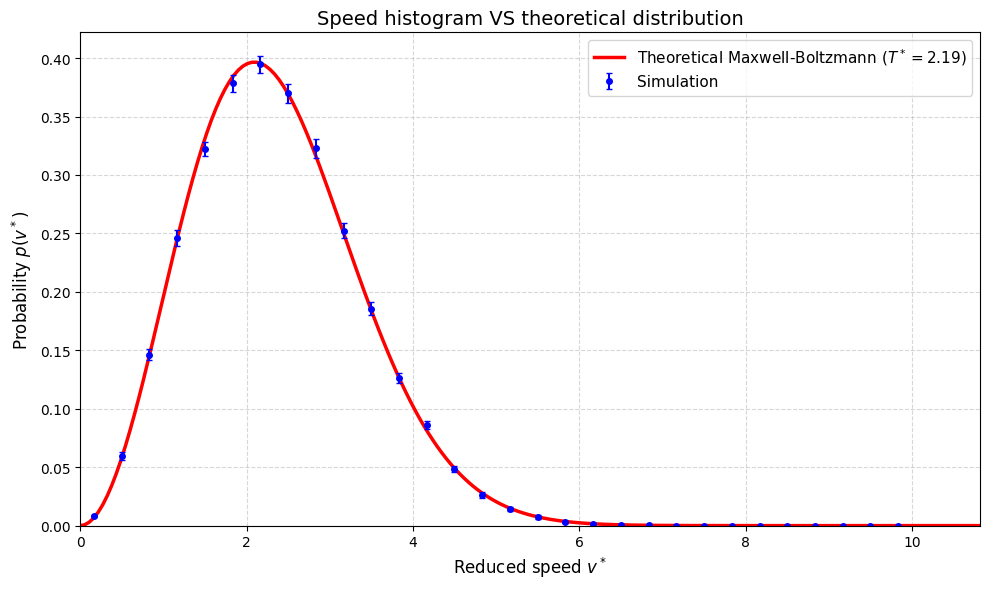

In [581]:
try:
    # Load data: v_sim represents the center of the velocity bins
    v_sim, p_v_sim, error_sim = np.loadtxt(path + 'pofv.dat', unpack=True)
    
except FileNotFoundError:
    print("ERROR: File " + path + "'OUTPUT/pofv.dat' not found.")
    print("Try changing path to 'NSL_SIMULATOR/OUTPUT/BACKUP/EX4.1/' if the files in OUTPUT have been deleted.")
    exit()

# ==========================================================
# Theoretical curve: MB distribution at temperature T_final
# ==========================================================
v_max = np.max(v_sim) * 1.1
v_theo = np.linspace(0, v_max, 200)
p_v_theo = maxwell_boltzmann(v_theo, T_final)

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(10, 6))

# Plot theoretical curve
plt.plot(v_theo, p_v_theo, 
         color='red', linestyle='-', linewidth=2.5,
         label=f'Theoretical Maxwell-Boltzmann ($T^* = {T_final:.2f}$)')

# Plot simulation data with errorbar
plt.errorbar(v_sim, p_v_sim, yerr=2*error_sim, 
             fmt='o', capsize=2.5, markersize=4, color='blue',
             label=f'Simulation')


plt.title('Speed histogram VS theoretical distribution', fontsize=14)
plt.xlabel('Reduced speed $v^*$', fontsize=12)
plt.ylabel('Probability $p(v^*)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.xlim(0, v_max)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

As shown in the previous plot, the simulated velocity distribution is well fitted by the theoretical Maxwell-Boltzmann profile. However, because some of the error bars are extremely small, in the following plot I display the residuals (the difference between the simulated data points and the exact theoretical curve).

By zooming in on the difference, we can make two important observations:
1. the residuals randomly fluctuate around zero showing no systematic shift;
2. the distance from the zero-line is compatible with the statistical uncertainties computed with the simulation.

Furthermore, the magnitude of the error bars correctly reflects the underlying counting statistics: they are visibly larger near the peak of the distribution and shrink towards the tails. This behavior arises because the number of particles $N$ falling into a specific velocity bin follows a Poissonian (or multinomial) distribution, where statistical fluctuations scale as $\sqrt{N}$. Therefore, the absolute statistical uncertainty is inherently greater in the most highly populated bins.

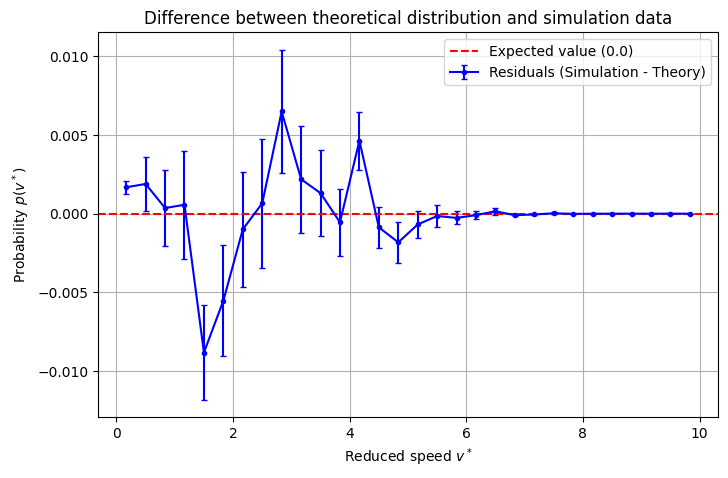

In [582]:
plt.figure(figsize=(8, 5))

plt.errorbar(v_sim, p_v_sim - maxwell_boltzmann(v_sim, T_final), yerr=error_sim, marker='.', capsize=2.5, linestyle='-', color='blue', label='Residuals (Simulation - Theory)')

plt.title('Difference between theoretical distribution and simulation data')
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Reduced speed $v^*$')
plt.ylabel('Probability $p(v^*)$')
plt.legend()
plt.grid(True)

plt.show()

### Chi2 with all data

[Asked Gemini what went wrong and how it could be justified, not entirely sure about the answer]

To quantitatively evaluate the agreement between the simulated velocity distribution and the theoretical Maxwell-Boltzmann (MB) curve, a rigorous $\chi^2$ test was performed. The calculation appropriately incorporated the statistical uncertainties (error bars) derived from the data blocking method.

The test over the valid bins yielded a total $\chi^2 \approx 45.0$, which corresponds to a reduced $\chi^2 \approx 2.14$ and a $p\text{-value} \approx 0.001713$. From a strict statistical standpoint, this leads to the rejection of the null hypothesis that the speed distribution is a MB.

In [583]:
from scipy.stats import chi2

expected = maxwell_boltzmann(v_sim, T_final)
observed = p_v_sim

valid_bins = error_sim > 0
obs_val = observed[valid_bins]
exp_val = expected[valid_bins]
err_val = error_sim[valid_bins]

chi_2_val = np.sum(((obs_val - exp_val) ** 2) / (err_val ** 2))

df = len(obs_val) - 2

p_value = 1 - chi2.cdf(chi_2_val, df=df)

print("\n======================================= \nCHI2 WITH ALL DATA\n=======================================")

print(f"Chi-squared statistic: {chi_2_val:.4f}")
print(f"Degrees of freedom: {df}")
print(f"Reduced Chi-squared: {chi_2_val / df:.4f}")
print(f"P-value: {p_value:.6f}")

    


CHI2 WITH ALL DATA
Chi-squared statistic: 45.0356
Degrees of freedom: 21
Reduced Chi-squared: 2.1446
P-value: 0.001713


### Chi2 removing outliers

[Still Gemini response]

However, further investigation into the individual bin contributions reveals the underlying physical reasons for this discrepancy. By manually isolating the most problematic bins, it becomes clear that a massive portion of the $\chi^2$ penalty originates from the very first bin (`[0]`), corresponding to near-zero velocities. The deviation in this specific bin is near $4\sigma$.

This failure is not indicative of a bug or an incomplete thermalization (running the simulation for 10000 steps per block brings little improvement with respect to the initial 5000 steps), but is a classic manifestation of **Finite-Size Effects** and ensemble differences:
1. **NVE vs NVT Ensembles:** The theoretical MB distribution rigorously applies to the Canonical ensemble (NVT) in the thermodynamic limit ($N \to \infty$). Our Molecular Dynamics simulation, instead, integrates equations of motion in the Microcanonical ensemble (NVE) with only $N=108$ particles. In such a small, isolated system, the constraint of constant total energy strongly suppresses extreme fluctuations (like particles being completely at rest), causing an intrinsic deviation of order $\mathcal{O}(1/N)$ from the NVT theoretical curve.
2. **Phase Space at $v \to 0$:** At extremely low speeds, the available volume in phase space ($4\pi v^2 dv$) is vanishingly small. The combination of discrete numerical integration (Verlet algorithm) and periodic boundary conditions heavily affects the sampling of these extremely rare near-zero states.

In conclusion, while the $\chi^2$ test technically fails due to the strictness of the NVT theoretical model, the visual agreement, the expected scaling of the uncertainties, and the physical justification of the deviations prove that the Lennard-Jones gas has been correctly simulated and thermalized.


Possible responsible points for the divergence
Outliers at indices: [ 0  4 12]

CHERRY PICKING EXLUDING ALL OUTLIERS
Chi-squared statistic: 14.6600
Degrees of freedom: 18
Reduced Chi-squared: 0.8144
P-value: 0.685167


Outlier at index 0: (observed - expected)\error = 3.91 sigma
Outlier at index 4: (observed - expected)\error = -2.95 sigma
Outlier at index 12: (observed - expected)\error = 2.52 sigma


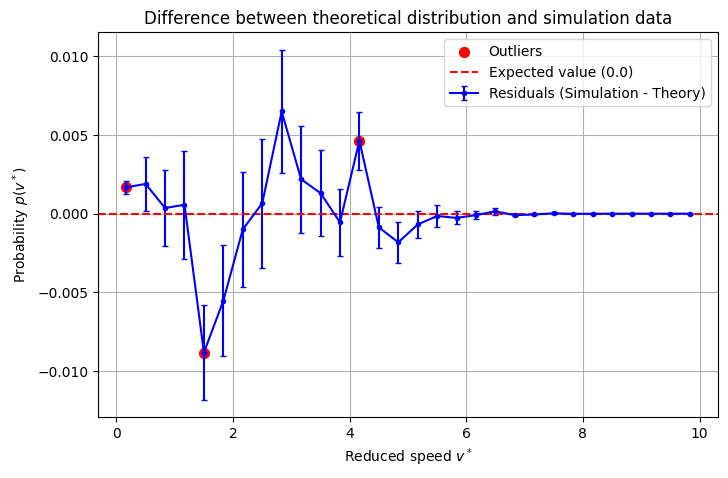


CHERRY PICKING ONLY EXCLUDING [0]
Chi-squared statistic: 29.7164
Degrees of freedom: 20
Reduced Chi-squared: 1.6509
P-value: 0.040297


In [584]:
print("\nPossible responsible points for the divergence")
outliers = np.where(np.abs(obs_val - exp_val) > 2 * err_val)[0]
print(f"Outliers at indices: {outliers}")

print("\n======================================= \nCHERRY PICKING EXLUDING ALL OUTLIERS\n=======================================")
# This is cherry picking, perfectly aware it's not the way to proceed, but I want to test without the problematic values
obs_cut = np.delete(obs_val, outliers)
exp_cut = np.delete(exp_val, outliers)
err_cut = np.delete(err_val, outliers)

chi_2_val = np.sum(((obs_cut - exp_cut) ** 2) / (err_cut ** 2))

df = len(obs_cut) - 2

p_value = 1 - chi2.cdf(chi_2_val, df=df)

print(f"Chi-squared statistic: {chi_2_val:.4f}")
print(f"Degrees of freedom: {df}")
print(f"Reduced Chi-squared: {chi_2_val / df:.4f}")
print(f"P-value: {p_value:.6f}")

print("\n")

# Print outliers values
for idx in outliers:
    print(f"Outlier at index {idx}: (observed - expected)\error = {(obs_val[idx] - exp_val[idx]) / err_val[idx]:.2f} sigma")

# Highlight the points responsible for the divergence
plt.figure(figsize=(8, 5))

plt.errorbar(v_sim, p_v_sim - maxwell_boltzmann(v_sim, T_final), yerr=error_sim, marker='.', capsize=2.5, linestyle='-', color='blue', label='Residuals (Simulation - Theory)')

# Plot the outliers in red
plt.scatter(v_sim[outliers], (obs_val - exp_val)[outliers], color='red', s=50, label='Outliers')

plt.title('Difference between theoretical distribution and simulation data')
plt.axhline(0, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Reduced speed $v^*$')
plt.ylabel('Probability $p(v^*)$')
plt.legend()
plt.grid(True)

plt.show()

print("\n======================================= \nCHERRY PICKING ONLY EXCLUDING [0]\n=======================================")

outliers = [0] # only the first bin

obs_cut0 = np.delete(obs_val, outliers)
exp_cut0 = np.delete(exp_val, outliers)
err_cut0 = np.delete(err_val, outliers)

chi_2_val0 = np.sum(((obs_cut0 - exp_cut0) ** 2) / (err_cut0 ** 2))

df0 = len(obs_cut0) - 2

p_value0 = 1 - chi2.cdf(chi_2_val0, df=df)

print(f"Chi-squared statistic: {chi_2_val0:.4f}")
print(f"Degrees of freedom: {df0}")
print(f"Reduced Chi-squared: {chi_2_val0 / df:.4f}")
print(f"P-value: {p_value0:.6f}")



Possible reasons why chi2 test does not pass:
- The speed distribution actually does not approach the maxwell-boltzmann yet (try more steps per block (tried 10000 steps and 40 blocks and does not get better)?):
    - increasing number of steps does not work: maybe too few particles. The Maxwell-Boltzmann distribution is valid in the Thermodynamical limit ($N\rightarrow\infty$)
- The probability computed with chi2 is not satisfactory because of the very little data we have (appreciable data are basically only 19: deleted all data that have error 0)

# Analysis Exercise 4.2: evolution starting from low entropy state

In [585]:
# ==========================================
# PATHS
# ==========================================

path = "NSL_SIMULATOR/OUTPUT/" # if the files in OUTPUT have been deleted, a successful simulation result is stored in OUTPUT/BACKUP/EX4.2/
# Comment the previous line and uncomment the following one if the files in OUTPUT get lost
#path = "NSL_SIMULATOR/OUTPUT/BACKUP/EX4.2/" 

In this part of the exercise, the goal is to observe the evolution of the gas starting from a highly improbable, low-entropy initial state. Specifically, the particles are spatially confined to one-eighth of the total volume, and their initial velocities are sampled from a Dirac delta distribution, $p(v^*, 0) = \delta(v^* - v^*_{T^*})$. Practically, this is achieved by assigning a velocity of magnitude $v^*_{T^*}$ along a single spatial dimension (e.g. the $x$-axis), while setting the $y$ and $z$ components to zero.

The initial spatial configuration is still the ideal lattice, in `NSL_SIMULATOR/INPUT/CONFIG/config.fcc`, copied into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`. In the C++ code `NSL_SIMULATOR/SOURCE/system.cpp`, the three spatial coordinates were halved during the read-in phase in the `read_configuration` function. This halving is strictly executed only if `RESTART == 0` in `NSL_SIMULATOR/INPUT/input.dat` (i.e., at the very beginning of the simulation), a condition that will become crucial in Exercise 4.3 to avoid shrinking the system again during the time inversion.

To track the evolution of the velocity distribution, the progressive averaging block from Exercise 4.1 was disabled. Instead, the code was modified to output the instantaneous block averages of the velocity histogram for specific snapshots (blocks 1, 2, 3, 5, 10, 20, 50, 100, 500, and 1000). The simulation was run for `NBLOCKS = 1000` of `NSTEPS = 50` (1000 blocks of 50 steps each). Using short blocks allows for a fine-grained observation of the probability density evolution during the early transient phase, while 50000 total steps ensure that the system safely reaches thermalization.

At the beginning, the system exhibits a velocity distribution sharply peaked at $v_{init}$ (indicated by the red dashed line in the plots). As the simulation progresses, the system thermalizes and the velocities naturally relax towards the Maxwell-Boltzmann distribution. 

By monitoring the temperature, a mostly flat asymptotic behavior is visible towards the end of the simulation. Therefore, as a reference temperature for the theoretical Maxwell-Boltzmann curve, the temperature was averaged over the final equilibrium phase (from block 400 to 1000). 

The results clearly show that after about 100 blocks (5000 steps), the velocity distribution already provides a solid approximation of the theoretical Maxwell-Boltzmann curve at the final thermalized temperature.

## Thermalization process

To compute the reference temperature for the theoretical Maxwell-Boltzmann curve, I analyzed the data from `NSL_SIMULATOR/OUTPUT/temperature.dat`. Specifically, I extracted the `ACTUAL_T` field, which represents the instantaneous temperature averaged over each individual block, rather than using the progressive global average. This choice is crucial because the initial blocks capture the system's non-equilibrium transient phase: including them in a global average would artificially skew the final result. By using `ACTUAL_T`, I could restrict the average strictly to the (quasi-)thermalized state.

As shown in the plot, the system reaches a stable, thermalized regime from block 400 onwards. Therefore, I averaged the temperatures exclusively from block 400 to 1000 to obtain the final reference temperature.

After the simulation finished I renamed the file `temperature_4.2.dat` to avoid overwriting it in later simulations

============ Mean equilibrium temperature (averaged on blocks from 400 to 1000): T* = 1.33 ============


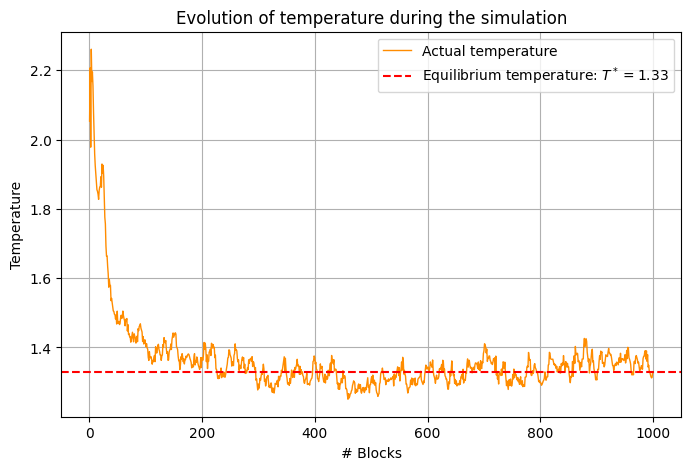

In [586]:
try: 
    blocks, actual_T, av_T, err_T = np.loadtxt(path + 'temperature_4.2.dat', unpack=True)
except FileNotFoundError:
    print("ERROR: File " + path + "'OUTPUT/temperature_4.2.dat' not found.")
    print("Try changing path to 'NSL_SIMULATOR/OUTPUT/BACKUP/EX4.2/' if the files in OUTPUT have been deleted.")
    exit()

# Calculate the equilibrium temperature
thermalized_temperatures = actual_T[400:]
T_final = np.mean(thermalized_temperatures)

print(f"============ Mean equilibrium temperature (averaged on blocks from 400 to 1000): T* = {T_final:.2f} ============")

# Plot the temperature evolution
plt.figure(figsize=(8, 5))

plt.plot(blocks, actual_T, linewidth=1, color='darkorange', label='Actual temperature')
plt.axhline(T_final, color='red', linestyle='--', label=f'Equilibrium temperature: $T^*={T_final:.2f}$')

plt.xlabel('# Blocks')
plt.ylabel('Temperature')
plt.title('Evolution of temperature during the simulation')
plt.legend()
plt.grid()
plt.show()

### Convergence to the Maxwell-Boltzmann distribution

In the following plots, I show the convergence of the velocity distribution to the Maxwell-Boltzmann equilibrium distribution. The distribution of the velocity magnitudes has been obtained as described in the analysis of Exercise 4.1. At the end of block 1 (after 50 simulation steps), one can clearly see a well-centered peak around the initial value $v^*_{T^*} = \sqrt{3T^*}$ (the value of the initial temperature $T^*$ is found in `NSL_SIMULATOR/INPUT/input.dat` and is set to $T^*=2.0$). As the simulation proceeds, this peak starts to broaden and relax, naturally reshaping itself towards the theoretical Maxwell-Boltzmann distribution.

In [587]:
# ==========================================
# PARAMETERS SETTINGS
# ==========================================
 
saved_blocks = [1, 2, 3, 5, 10, 20, 50, 100, 500, 1000]

# Compute initial velocity from the initial temperature
T_init = 2.0  
v_init = np.sqrt(3 * T_init) 

# T_eff will be the reference temperature for the theoretical Maxwell-Boltzmann distribution
T_eff = T_final 

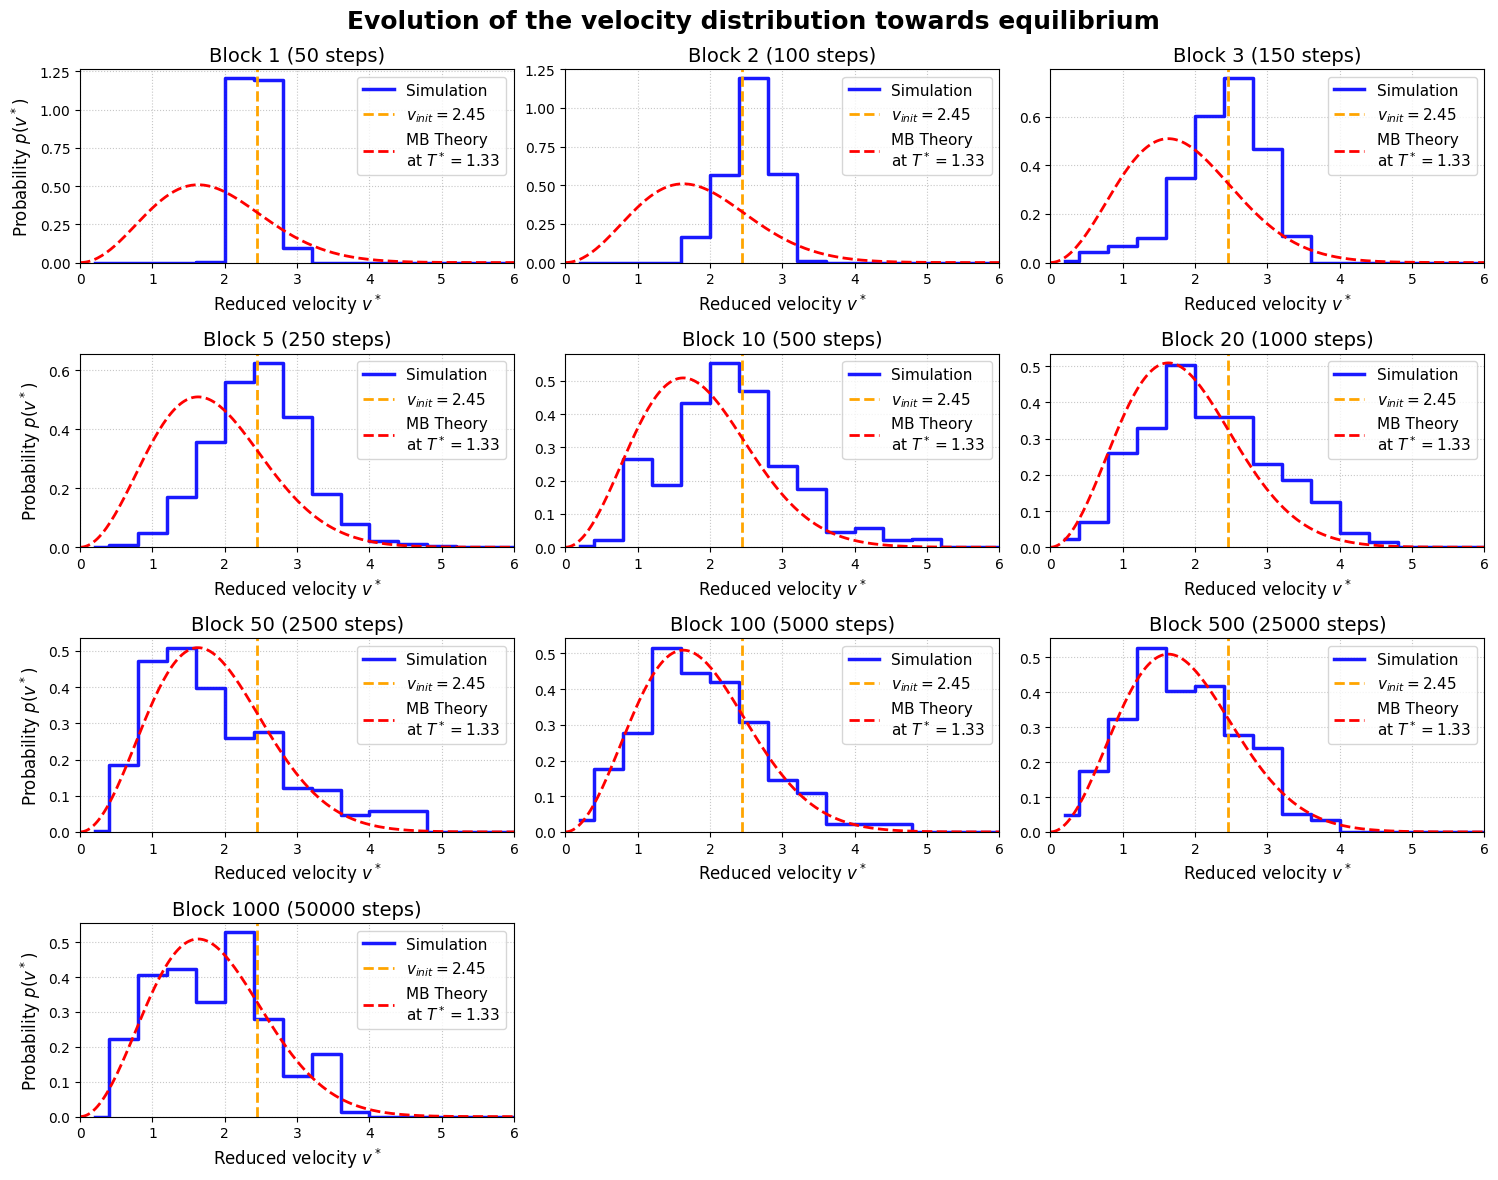

In [588]:
# ==========================================
# PLOTS
# ==========================================

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten() # Flatten the axes array for easy iteration with a for loop

# Generate the theoretical curve
v_theory = np.linspace(0, 6.0, 200) # 6.0 is the value set in Exercise 4.1, as maximum velocity range
p_theory = maxwell_boltzmann(v_theory, T_eff) # defined at the beginning of the notebook

fig.suptitle('Evolution of the velocity distribution towards equilibrium', fontsize=18, fontweight='bold', y=0.98)


for i, blk in enumerate(saved_blocks):
    ax = axes[i] # Select current subplot
    file_name = path + f'/pofv_block{blk}.dat'
    
    try:
        data = np.loadtxt(file_name)
        v_sim = data[:, 0] # First column: velocity bins
        p_sim = data[:, 1] # Second column: probability values

        # Plot the step histogram
        ax.step(v_sim, p_sim, where='mid', color='blue', alpha=0.9, 
                 linewidth=2.5, label='Simulation') # where='mid' takes into account that the velocity values are the centers of the bins
        
    except FileNotFoundError: # if file does not exist program does not crash but shows a message in the subplot
        ax.text(0.5, 0.5, f"File Block {blk}\nnot found", 
                ha='center', va='center', color='red', transform=ax.transAxes)

    # Plot reference lines
    ax.axvline(v_init, color='orange', linestyle='--', linewidth=2, label=f'$v_{{init}} = {v_init:.2f}$')
    ax.plot(v_theory, p_theory, color='red', linestyle='--', linewidth=2, label=f'MB Theory\nat $T^*={T_final:.2f}$')

    # Subplot aesthetics
    ax.set_title(f'Block {blk} ({blk * 50} steps)', fontsize=14)
    ax.set_xlim(0, 6.0) 
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    # Set axis labels
    ax.set_xlabel('Reduced velocity $v^*$', fontsize=12)
    if i % 3 == 0: 
        ax.set_ylabel('Probability $p(v^*)$', fontsize=12)
        
    # Add legend only to the first plot
    #if i == 0:
    ax.legend(fontsize=11, loc='upper right')



# This removes the empty plots
for j in range(len(saved_blocks), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.subplots_adjust(top=0.93) 
plt.show()

# Analysis Exercise 4.3: time reversibility and Lyapunov instability

In [589]:
# ==========================================
# PATHS
# ==========================================

path = "NSL_SIMULATOR/OUTPUT/" # if the files in OUTPUT have been deleted, a successful simulation result is stored in OUTPUT/BACKUP/EX4.3/
# Comment the previous line and uncomment the following one if the files in OUTPUT get lost
#path = "NSL_SIMULATOR/OUTPUT/BACKUP/EX4.3/" 

In this third part of the exercise, the goal is to test the reversibility properties of the Verlet algorithm. The Verlet integration scheme is properly centered, meaning that $\vec{r}(t-\Delta t)$ and $\vec{r}(t+\Delta t)$ play symmetrical roles in the equations, making the algorithm theoretically time-reversible.

The problem in practical time reversibility lies essentially in the finite precision of the computer. While the analytical truncation error of the algorithm is $\mathcal{O}(\Delta t^4)$, the true cause of the irreversibility observed in long simulations is the floating-point round-off error coupled with the inherently chaotic nature of a many-body interacting system. A Lennard-Jones gas is a strongly chaotic system characterized by **Lyapunov instability**. This implies that any microscopic perturbation—such as the unavoidable truncation of decimal digits at each numerical integration step—amplifies exponentially over time. Consequently, a tiny numerical error forces the computed trajectory to rapidly diverge from its theoretical, unperturbed mathematical path.

We demonstrate this phenomenon by running two separate simulations and subsequently reversing the time arrow (which, in a Verlet scheme, is achieved by swapping the current and previous spatial coordinates):

- **Short simulation ($5 \times 10^3$ steps):** the temporal inversion is successful because the exponentially growing numerical error has not yet reached a magnitude sufficient to destroy the memory of the forward trajectory. As shown in the plots, the potential energy, the kinetic energy, and the temperature almost perfectly retrace their path back to the initial crystalline configuration.
- **Long simulation ($5 \times 10^4$ steps):** here, the numerical error introduced by the computer's finite precision has had enough time to amplify exponentially due to the Lyapunov instability. When we attempt to reverse time, the backward integration starts with a minuscule floating-point discrepancy compared to the exact final state of the forward run. Because of chaos, this tiny difference grows step by step, completely separating the backward trajectory from the forward one. The system can no longer retrace its exact steps to rebuild the highly ordered initial solid lattice. Instead, it gets "lost" in phase space and remains trapped in the gas phase at thermodynamic equilibrium. 

Therefore, while the Verlet algorithm is mathematically time-reversible, the underlying physical chaos (Lyapunov instability) combined with finite numerical precision makes the long-term microscopic evolution practically irreversible.

## Steps to perform the simulation 
Take for example the **short simulation** ($5\times10^3$ steps)
- #### Forward simulation:
    - in `NSL_SIMULATOR/INPUT/input.dat` I set `RESTART = 0`, `NBLOCKS = 50`, `NSTEPS = 100`;
    - in `NSL_SIMULATOR/INPUT/properties.dat` I enabled the measurements for `TOTAL ENERGY`, `POTENTIAL ENERGY`, `KINETIC ENERGY` and `TEMPERATURE`;
    - I initialized the system using the perfect FCC lattice (by copying `NSL_SIMULATOR/INPUT/CONFIG/config.fcc` into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`). As done in the previous exercise, the coordinates are halved by the code during the read-in phase to confine the particles to one-eighth (half of the side in each dimension) of the total volume, creating a low-entropy initial state. The velocities are still initialized as in the previous exercise;
    - after the run I renamed the output files to avoid overwriting them in successive simulations;


- #### Backward simulation
    - To invert the direction of time, I cross-copied the final configurations: `NSL_SIMULATOR/OUTPUT/CONFIG/config.xyz` became the new `NSL_SIMULATOR/INPUT/CONFIG/conf-1.xyz`, and `NSL_SIMULATOR/OUTPUT/CONFIG/conf-1.xyz` became the new `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`. By doing this, the starting configuration is the second-to-last step of the forward simulation, and the "past" configuration is the final step, forcing the Verlet algorithm to compute reversed velocities.
    - in `NSL_SIMULATOR/INPUT/input.dat` I set `RESTART = 1`;
    - I started the simulation (notice that if `RESTART = 1` the code is instructed not to halve the particle positions again, preserving the correct expanded state of the gas);
    - Finally, I renamed the output files to safely store the backward trajectories.

Notice that the only adaptation to these steps to perform the **long simulation** ($5\times10^4$ steps) is to change the number of blocks to $500$ (`NBLOCKS = 500` in `NSL_SIMULATOR/INPUT/input.dat`)

In [590]:
# Names of files and titles for the plots
properties = ['poten', 'ken', 'toten', 'temp']
titles = ['Potential energy', 'Kinetic energy', 'Total energy', 'Temperature']
ylabels = ['U/N', 'K/N', 'E/N', 'T*']

In [591]:
# ==========================================
# PLOTTING FUNCTION
# ==========================================

def plot_reversibility(steps_label, n_blocks, zoom_window=None):
    
    # ===================
    # LAYOUT SETUP
    # ===================
    if zoom_window is None:
        # 2x2 grid for the 4 properties
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        axs = axs.flatten()
        fig.suptitle(f"Time Inversion Experiment - Run of {steps_label} steps", fontsize=16, fontweight='bold')
        
        props_to_plot = properties
        titles_to_plot = titles
        ylabels_to_plot = ylabels
    else:
        # 3x1 grid for 3 properties (excluding Total energy) with shared x-axis
        fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
        if isinstance(axs, np.ndarray) and axs.ndim > 1: axs = axs.flatten()
        fig.suptitle(f"Lyapunov Divergence Zoom (last {zoom_window} blocks) - Run of {steps_label} steps", fontsize=16, fontweight='bold')
        
        idx_keep = [i for i, p in enumerate(properties) if p != 'toten']
        props_to_plot = [properties[i] for i in idx_keep]
        titles_to_plot = [titles[i] for i in idx_keep]
        ylabels_to_plot = [ylabels[i] for i in idx_keep]

    for i, prop in enumerate(props_to_plot):
        file_fwd = f"{path}{prop}_forward_{steps_label}.dat"
        file_bwd = f"{path}{prop}_backward_{steps_label}.dat"

        try:
            
            # Load data from files
            data_fwd = np.loadtxt(file_fwd)
            data_bwd = np.loadtxt(file_bwd)

            # Column 0: # Block
            blk_fwd = data_fwd[:, 0]
            blk_bwd = data_bwd[:, 0]
            
            # Column 1: singol block average
            val_fwd = data_fwd[:, 1] 
            val_bwd = data_bwd[:, 1] 

            # ===================
            # TIME INVERSION
            # ===================
            # Block 1 of the backward simulation is equivalent to the last block of the forward simulation
            # If we reverse the "time axes" of the backward, we can see the overlap of the two trajectories
            #   - block 1 is mapped in block n_blocks (50/500)
            #   - block 2 is mapped in block n_blocks-1, and so on ...
            blk_bwd_reversed = n_blocks - blk_bwd + 1

            # Plot forward
            axs[i].plot(blk_fwd, val_fwd, label='Forward', 
                        color='blue', linewidth=2, alpha=0.7)
            
            # Plot backward (inverted)
            axs[i].plot(blk_bwd_reversed, val_bwd, label='Inverted Backward', 
                        color='crimson', linestyle='--', linewidth=2.5, alpha=0.9)

            
            # Set titles, labels and grid
            axs[i].set_title(titles_to_plot[i], fontsize=13)
            axs[i].set_ylabel(ylabels_to_plot[i], fontsize=11)
            axs[i].grid(True, linestyle=':', alpha=0.7)

            if zoom_window is None:
                axs[i].set_xlabel('# Block (time)', fontsize=11)
            else:
                if i == len(props_to_plot) - 1:
                    axs[i].set_xlabel('# Block (time)', fontsize=12)

            # === AXIS SCALE FOR TOTAL ENERGY ===
            # Total energy exhibits fluctuations on a much smaller scale than U and K: uncommenting the code below one can see that on the
            #  scale of K and U the total energy is basically a perfect constant

#           # ===============================================================
#            if prop == 'toten':
#                # Calculate mean value around which total energy fluctuates
#                mean_toten = np.mean(val_fwd)
#                # Scale of the U and K axis is about 1.5 units, so set a visual window of that size around the mean
#                axs[i].set_ylim(mean_toten - 0.75, mean_toten + 0.75)
#            # ===============================================================
            
            # Add legend
            axs[i].legend(fontsize=11)

            # ===================
            # ZOOM LOGIC
            # ===================
            if zoom_window is not None:
                # Zoom showing from block n_blocks - zoom_window to the end
                axs[i].set_xlim(n_blocks - zoom_window, n_blocks + 1)
                
        except FileNotFoundError:
            axs[i].text(0.5, 0.5, f"Files not found for {prop}", 
                        ha='center', va='center', color='red')

    plt.tight_layout()
    if zoom_window is None:
        plt.subplots_adjust(top=0.92)
    else:
        plt.subplots_adjust(top=0.94, hspace=0.1)
    plt.show()

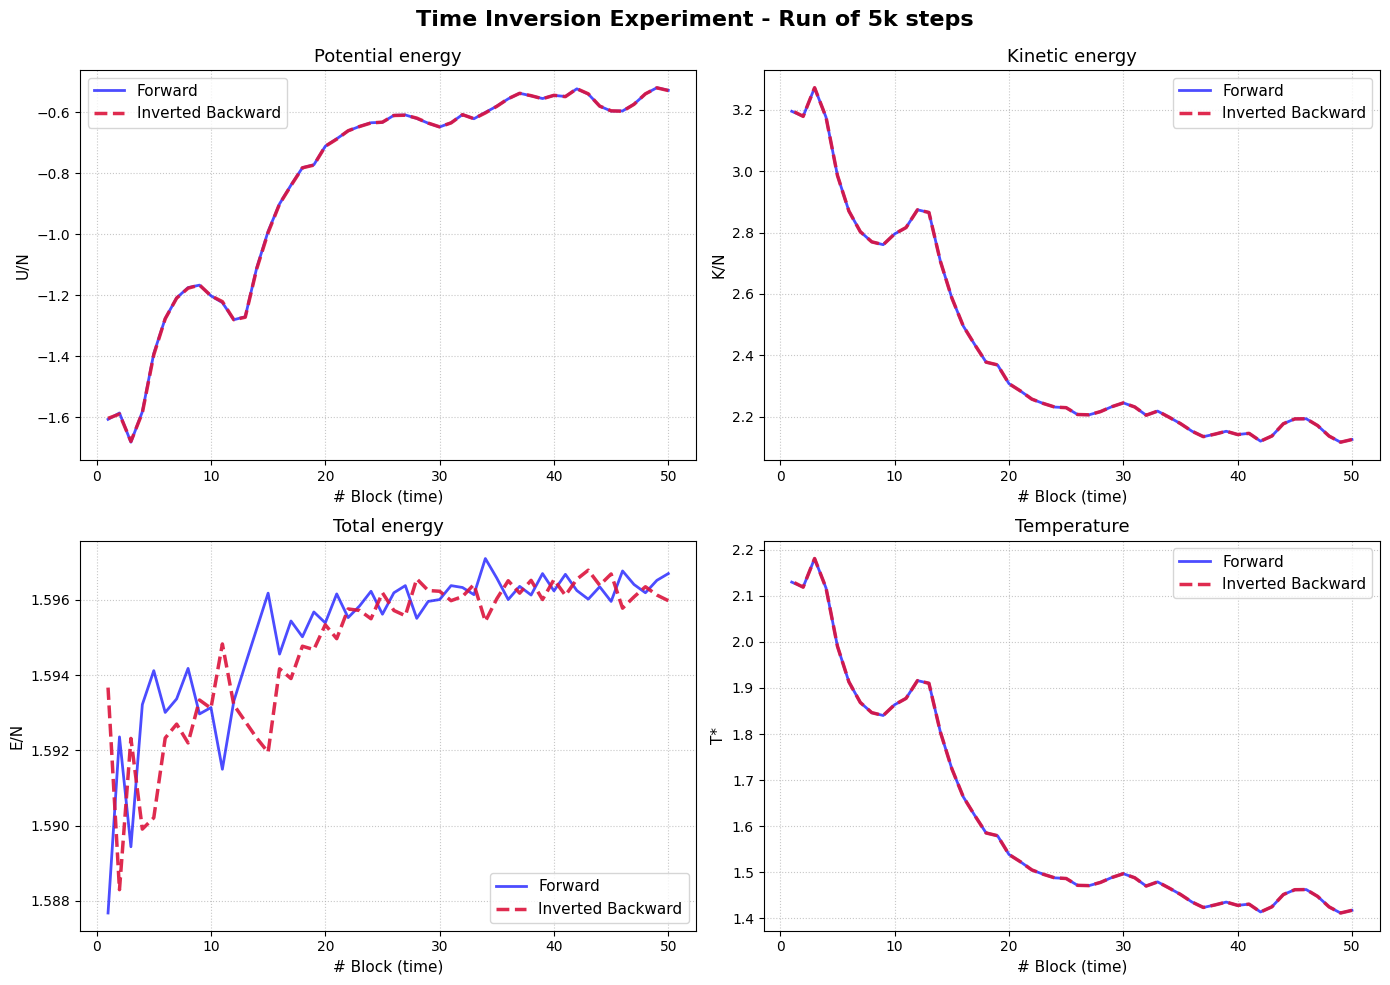

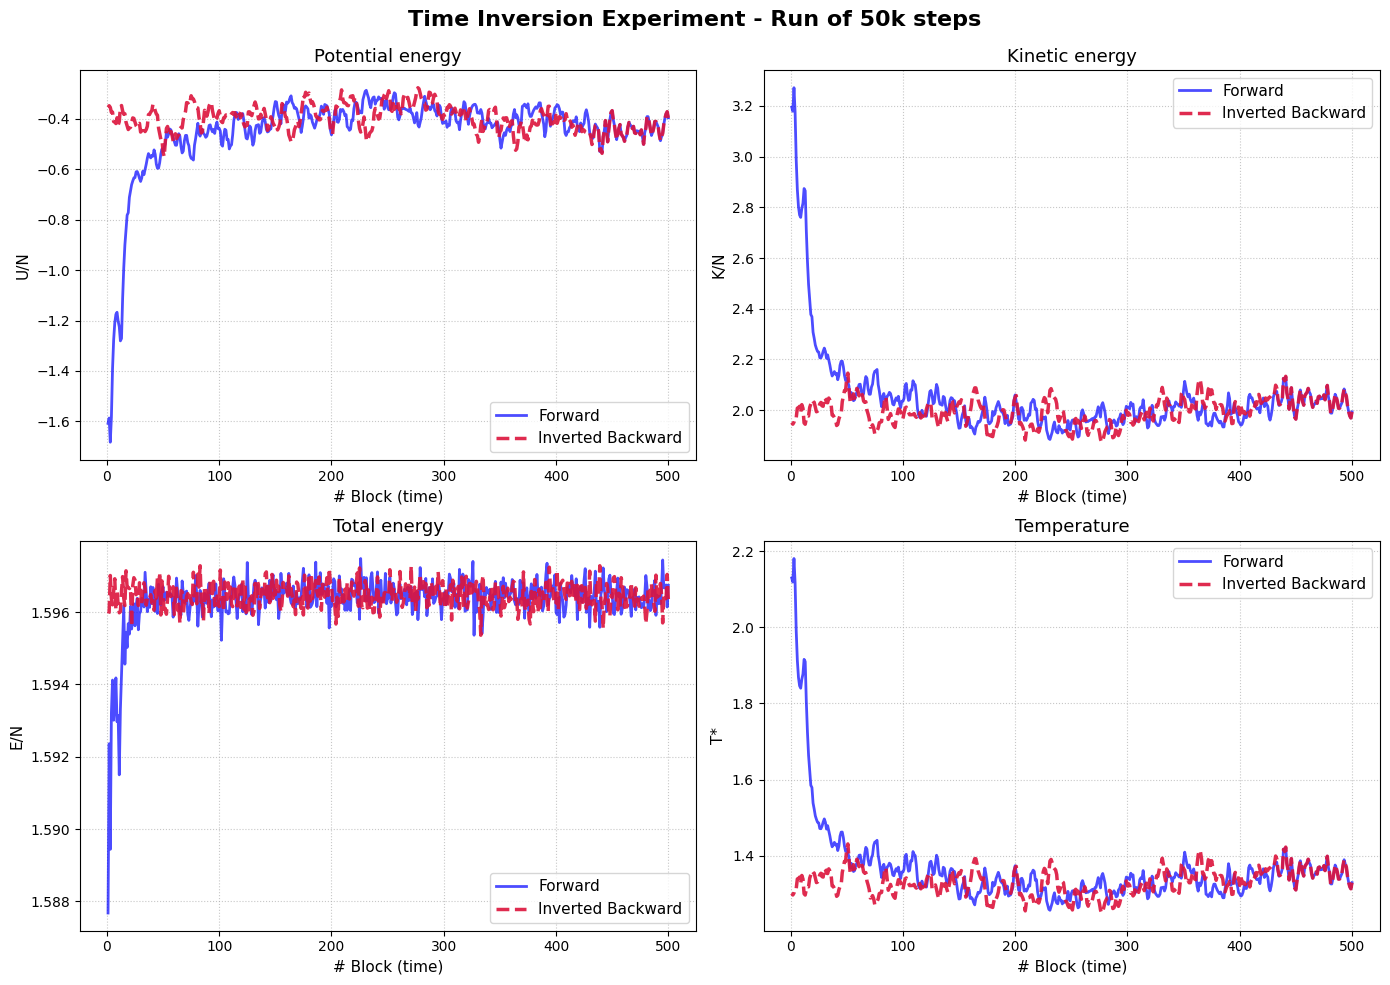

In [592]:
# ==========================================
# PLOT EXECUTION
# ==========================================
# For 5k: 50 blocks of 100 steps each (total 5000 steps)
plot_reversibility(steps_label='5k', n_blocks=50) 

# For 50k: 500 blocks of 100 steps each (total 50000 steps)
plot_reversibility(steps_label='50k', n_blocks=500)

### Onset of Lyapunov divergence

To better appreciate the exact moment the Lyapunov instability manifests, we produced a zoomed-in plot focusing on the 150 blocks immediately adjacent to the time-inversion event of the $5 \times 10^4$ steps simulation. 

As clearly depicted in the figures for potential energy, kinetic energy, and temperature, the onset of chaos is not instantaneous. Immediately after the time arrow is reversed, the backward trajectory (red dashed line) almost perfectly superimposes onto the forward reference trajectory (solid blue line). During these initial (reverted) blocks, the floating-point round-off error introduced by the computer is still microscopically small. It has not yet grown enough to alter the microscopic coordinates significantly, allowing the system to successfully and exactly retrace its recent past.

However, as the backward integration proceeds, the strongly chaotic nature of the Lennard-Jones system relentlessly amplifies these initially negligible numerical inaccuracies. After a few blocks, the exponential growth of the error reaches a critical threshold. 

This breaking point is highly visible in the plots: it is the exact moment the two curves split. From this point onward, the backward trajectory completely loses the memory of the original microscopic forward path. However, it is crucial to note that the two trajectories do not immediately diverge macroscopically. Both continue to explore the same vast region of phase space corresponding to the equilibrium gas, oscillating around the same thermodynamic averages.

The true macroscopic consequence of this chaotic memory loss becomes evident only at the very end of the backward integration. While the forward simulation originally started from a highly ordered, low-energy crystalline lattice, the backward trajectory cannot "find" its way back to this tiny, incredibly specific region of phase space. Because the microscopic synchronization was broken by the Lyapunov instability blocks earlier, the inverted system remains permanently trapped in the disordered gas phase, definitively proving that numerical chaos destroys the long-term reversibility of the Verlet algorithm.

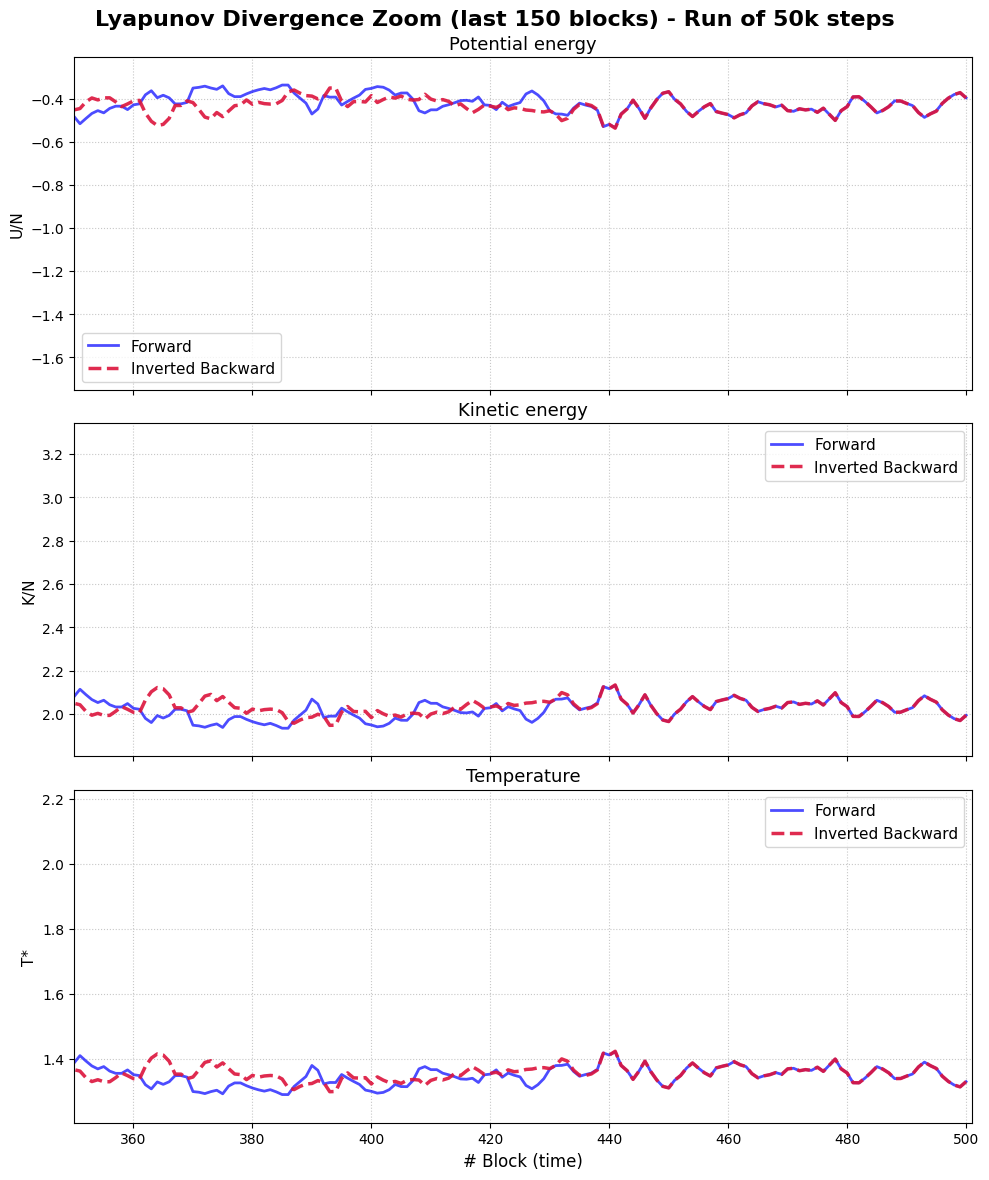

In [593]:
# ============================================
# ZOOM IN ON THE ONSET OF LYAPUNOV DIVERGENCE
# ============================================

# For 50k: 500 blocks of 100 steps each (total 50000 steps): zoom in on the last 150 blocks around the time inversion event
plot_reversibility(steps_label='50k', n_blocks=500, zoom_window=150)